In [104]:
import pandas as pd

In [106]:
co2data = pd.read_csv('C:/Users/clare/Downloads/Trainingprojects/CO2 Dataset.csv')

In [19]:
print (co2data.dtypes)

Country                object
ISO 3166-1 alpha-3     object
Year                    int64
Total                 float64
Coal                  float64
Oil                   float64
Gas                   float64
Cement                float64
Flaring               float64
Other                 float64
Per Capita            float64
dtype: object


In [108]:
co2data.head()

,Country,ISO 3166-1 alpha-3,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
0,Afghanistan,AFG,1750,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1751,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1752,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1753,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1754,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
co2data.shape

(63104, 11)

In [27]:
print(co2data[co2data['Year'] < 1950]['Total'].value_counts())

0.000000       39499
0.003664         101
0.025648          22
0.007328          21
0.040304          18
               ...  
198.848944         1
186.347376         1
170.390656         1
163.033344         1
5245.849343        1
Name: Total, Length: 5412, dtype: int64


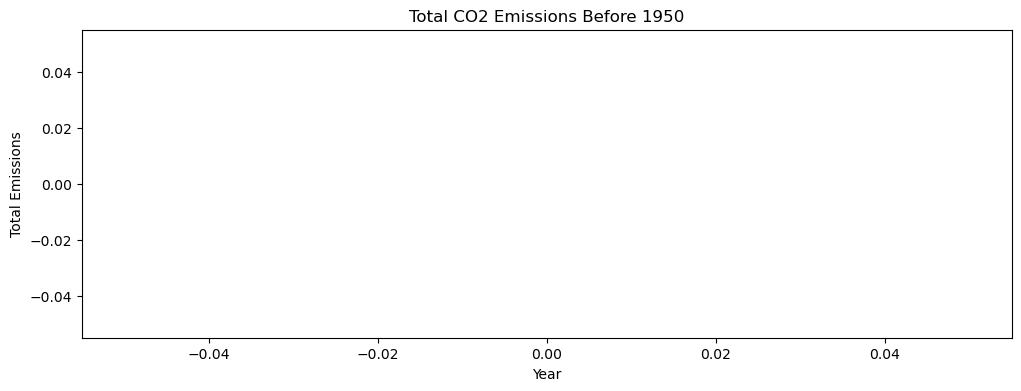

In [102]:
import matplotlib.pyplot as plt

co2data[co2data['Year'] < 1950].groupby('Year')['Total'].sum().plot(figsize=(12,4))
plt.title('Total CO2 Emissions Before 1950')
plt.xlabel('Year')
plt.ylabel('Total Emissions')
plt.show()

In [114]:
co2data[co2data['Year'] < 1950].head(30)

,Country,ISO 3166-1 alpha-3,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
0,Afghanistan,AFG,1750,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1751,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1752,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1753,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1754,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,AFG,1755,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,AFG,1756,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,AFG,1757,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,AFG,1758,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,AFG,1759,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
co2data = co2data[co2data['Year'] >= 1950]
co2data = co2data[co2data['Total'] > 0]
co2data.shape

(14996, 11)

In [35]:
print(co2data.isnull().sum())

Country                   0
ISO 3166-1 alpha-3       83
Year                      0
Total                     0
Coal                     72
Oil                       0
Gas                      72
Cement                  251
Flaring                  72
Other                 13422
Per Capita               72
dtype: int64


In [40]:
print(co2data.describe())

               Year         Total          Coal           Oil           Gas  \
count  14996.000000  14996.000000  14924.000000  14996.000000  14924.000000   
mean    1986.745132    201.682545     81.843762     77.313674     33.442962   
std       20.544651   1662.929292    694.873405    621.972153    297.422394   
min     1950.000000      0.003593      0.000000      0.000000      0.000000   
25%     1969.000000      0.516624      0.000000      0.436016      0.000000   
50%     1987.000000      4.470919      0.040430      2.510010      0.000000   
75%     2005.000000     37.814028      5.027863     17.158498      3.012997   
max     2021.000000  37123.850352  15051.512770  12345.653374   7921.829472   

             Cement       Flaring        Other    Per Capita  
count  14745.000000  14924.000000  1574.000000  14924.000000  
mean       5.999937      2.473102    11.192173      5.262100  
std       59.669339     20.053590    39.574624     19.526109  
min        0.000000      0.000000   

In [42]:
co2data = co2data.drop(columns=['ISO 3166-1 alpha-3'])
print(co2data.shape)

(14996, 10)


In [44]:
from sklearn.model_selection import train_test_split

# First split off test set (20%)
train_val, test = train_test_split(co2data, test_size=0.2, random_state=42)

# Then split the remaining into train and validate (75/25 of remaining = 60/20 overall)
train, validate = train_test_split(train_val, test_size=0.25, random_state=42)

print(f"Train: {train.shape}")
print(f"Validate: {validate.shape}")
print(f"Test: {test.shape}")

Train: (8997, 10)
Validate: (2999, 10)
Test: (3000, 10)


In [46]:
cols = ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']

# Calculate median from training set only
train_median = train[cols].median()

# Apply to all three sets
train[cols] = train[cols].fillna(train_median)
validate[cols] = validate[cols].fillna(train_median)
test[cols] = test[cols].fillna(train_median)

# Confirm no missing values remain
print(train.isnull().sum())
print(validate.isnull().sum())
print(test.isnull().sum())

Country       0
Year          0
Total         0
Coal          0
Oil           0
Gas           0
Cement        0
Flaring       0
Other         0
Per Capita    0
dtype: int64
Country       0
Year          0
Total         0
Coal          0
Oil           0
Gas           0
Cement        0
Flaring       0
Other         0
Per Capita    0
dtype: int64
Country       0
Year          0
Total         0
Coal          0
Oil           0
Gas           0
Cement        0
Flaring       0
Other         0
Per Capita    0
dtype: int64


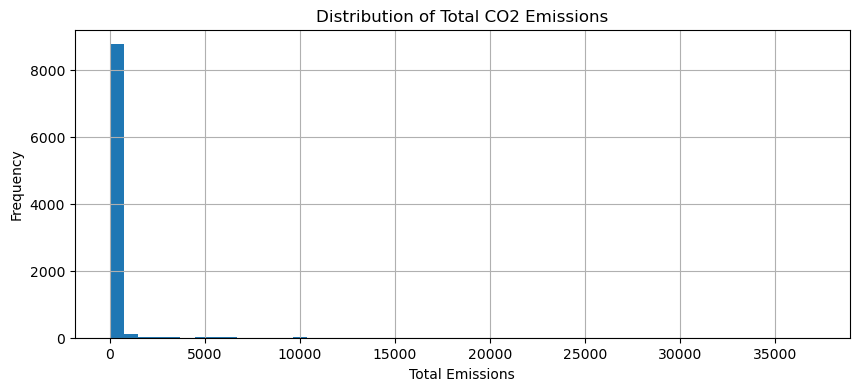

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

train['Total'].hist(bins=50, figsize=(10,4))
plt.title('Distribution of Total CO2 Emissions')
plt.xlabel('Total Emissions')
plt.ylabel('Frequency')
plt.show()

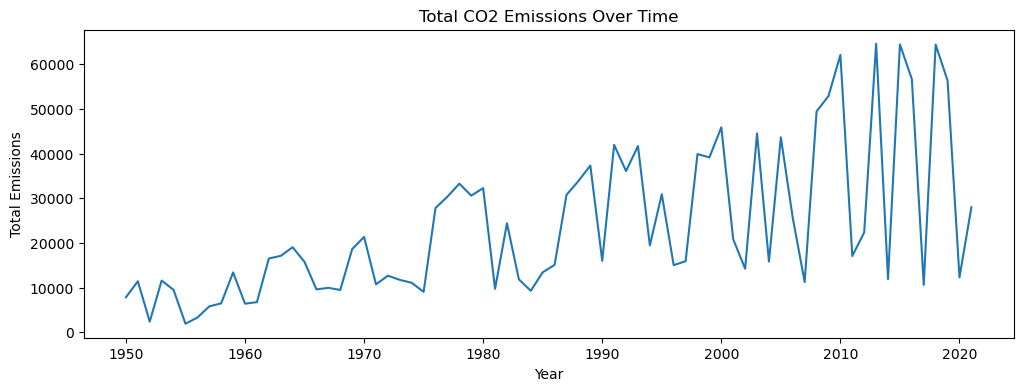

In [50]:
train.groupby('Year')['Total'].sum().plot(figsize=(12,4))
plt.title('Total CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total Emissions')
plt.show()

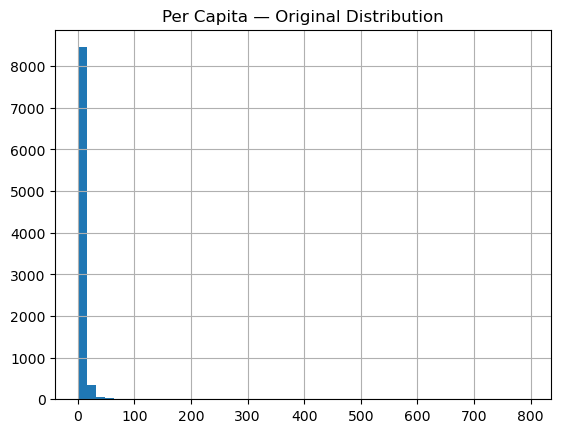

In [86]:
import matplotlib.pyplot as plt
train['Per Capita'].hist(bins=50)
plt.title('Per Capita — Original Distribution')
plt.show()

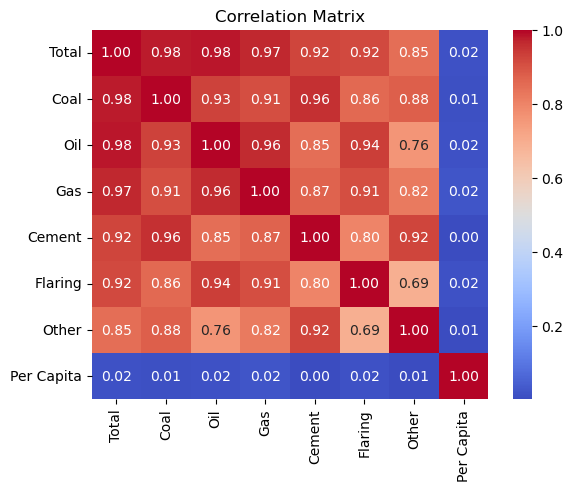

In [87]:
numeric_cols = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [54]:
# --- Step: Check duplicates ---
print("Full-row duplicates:", co2data.duplicated().sum())
print("Country + Year duplicates:", co2data.duplicated(subset=['Country', 'Year']).sum())

Full-row duplicates: 0
Country + Year duplicates: 0


In [56]:

import numpy as np

comp = ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other']

# NaN in components means zero — proven because Total = exact sum
train[comp] = train[comp].fillna(0)
validate[comp] = validate[comp].fillna(0)
test[comp] = test[comp].fillna(0)

# Drop rows where Per Capita is 0 (can't take log of zero)
train = train[train['Per Capita'] > 0].copy()
validate = validate[validate['Per Capita'] > 0].copy()
test = test[test['Per Capita'] > 0].copy()

print("Train:", train.shape)
print("Validate:", validate.shape)
print("Test:", test.shape)


Train: (8934, 10)
Validate: (2971, 10)
Test: (2980, 10)


In [58]:
# Compute fuel mix shares (each component as a fraction of Total)
for c in comp:
    train[c + '_share'] = train[c] / train['Total']
    validate[c + '_share'] = validate[c] / validate['Total']
    test[c + '_share'] = test[c] / test['Total']

# Check they look sensible
share_cols = [c + '_share' for c in comp]
print(train[share_cols].describe().round(3))

       Coal_share  Oil_share  Gas_share  Cement_share  Flaring_share  \
count    8934.000   8934.000   8934.000      8934.000       8934.000   
mean        0.171      0.690      0.087         0.037          0.021   
std         0.259      0.305      0.163         0.206          0.091   
min         0.000      0.000      0.000         0.000          0.000   
25%         0.000      0.444      0.000         0.000          0.000   
50%         0.016      0.774      0.000         0.018          0.000   
75%         0.269      1.000      0.107         0.045          0.000   
max         1.000      1.000      0.967         8.314          0.949   

       Other_share  
count     8934.000  
mean         7.476  
std         30.895  
min          0.000  
25%          0.024  
50%          0.252  
75%          2.278  
max        347.377  


In [60]:
# Drop Other_share (broken) and Coal_share (baseline reference)
features = ['Oil_share', 'Gas_share', 'Cement_share', 'Flaring_share', 'Year']

print("Features:", features)
print("Target: log(Per Capita)")

Features: ['Oil_share', 'Gas_share', 'Cement_share', 'Flaring_share', 'Year']
Target: log(Per Capita)


In [62]:
# Log transform Per Capita (fixes the right skew)
train['log_pc'] = np.log(train['Per Capita'])
validate['log_pc'] = np.log(validate['Per Capita'])
test['log_pc'] = np.log(test['Per Capita'])

print("log_pc sample stats:")
print(train['log_pc'].describe().round(3))

log_pc sample stats:
count    8934.000
mean        0.418
std         1.784
min        -5.965
25%        -0.834
50%         0.687
75%         1.830
max         6.680
Name: log_pc, dtype: float64


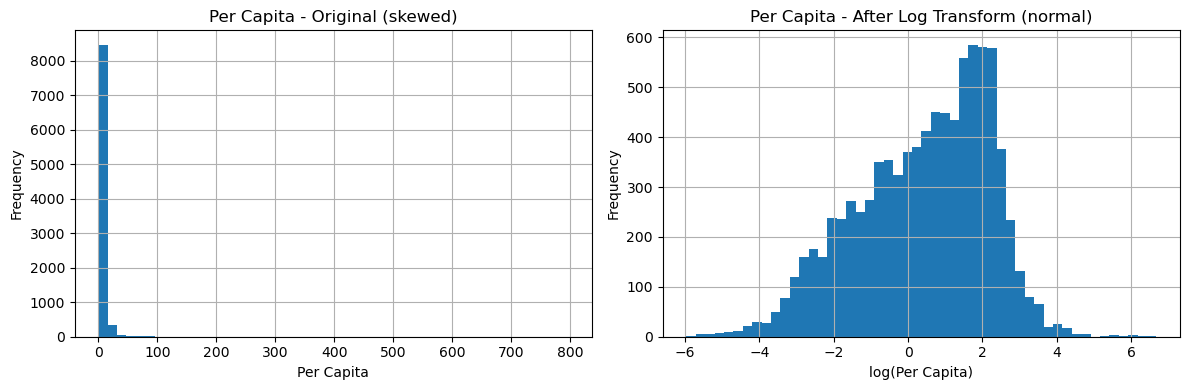

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before log transform
train['Per Capita'].hist(bins=50, ax=axes[0])
axes[0].set_title('Per Capita - Original (skewed)')
axes[0].set_xlabel('Per Capita')
axes[0].set_ylabel('Frequency')

# After log transform
train['log_pc'].hist(bins=50, ax=axes[1])
axes[1].set_title('Per Capita - After Log Transform (normal)')
axes[1].set_xlabel('log(Per Capita)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [66]:
# Standardise features using TRAIN stats only (no leakage)
X_train = train[features].copy()
X_validate = validate[features].copy()
X_test = test[features].copy()

mu = X_train.mean()
sigma = X_train.std()

X_train = (X_train - mu) / sigma
X_validate = (X_validate - mu) / sigma
X_test = (X_test - mu) / sigma

y_train = train['log_pc']
y_validate = validate['log_pc']
y_test = test['log_pc']

print("X_train shape:", X_train.shape)
print("Feature means after scaling (should be ~0):")
print(X_train.mean().round(3))

X_train shape: (8934, 5)
Feature means after scaling (should be ~0):
Oil_share        0.0
Gas_share       -0.0
Cement_share     0.0
Flaring_share   -0.0
Year            -0.0
dtype: float64


In [80]:
import statsmodels.api as sm

# Add constant (intercept) for OLS
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)
X_validate_ols = sm.add_constant(X_validate)   # ← add it here

# Fit model
ols_model = sm.OLS(y_train, X_train_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 log_pc   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     525.4
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:03:41   Log-Likelihood:                -16695.
No. Observations:                8934   AIC:                         3.340e+04
Df Residuals:                    8928   BIC:                         3.344e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4180      0.017     25.192

In [82]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on validate set
ols_val_preds = ols_model.predict(X_validate_ols)
rf_val_preds = rf_model.predict(X_validate)
print("OLS  R² on validate:", round(r2_score(y_validate, ols_val_preds), 3))
print("RF   R² on validate:", round(r2_score(y_validate, rf_val_preds), 3))

# Evaluate on test set
ols_preds = ols_model.predict(X_test_ols)
rf_preds = rf_model.predict(X_test)
print("OLS  R² on test:", round(r2_score(y_test, ols_preds), 3))
print("RF   R² on test:", round(r2_score(y_test, rf_preds), 3))
print("OLS  RMSE on test:", round(np.sqrt(mean_squared_error(y_test, ols_preds)), 3))
print("RF   RMSE on test:", round(np.sqrt(mean_squared_error(y_test, rf_preds)), 3))

OLS  R² on validate: 0.217
RF   R² on validate: 0.469
OLS  R² on test: 0.219
RF   R² on test: 0.488
OLS  RMSE on test: 1.577
RF   RMSE on test: 1.276


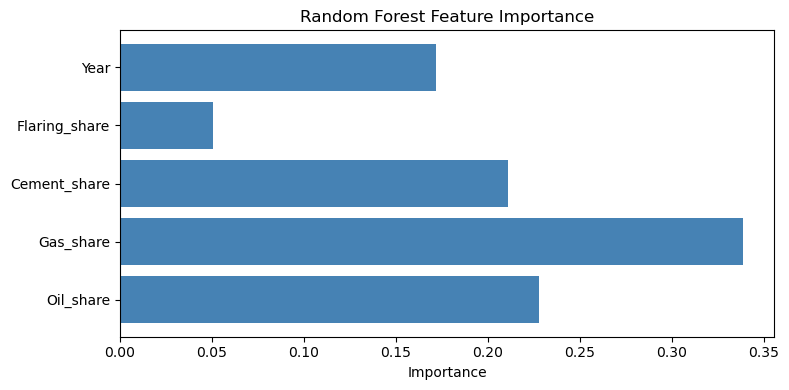

In [84]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feat_names = features

plt.figure(figsize=(8, 4))
plt.barh(feat_names, importances, color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()